### 5.0. Importando o modelo final

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from joblib import load

In [ ]:
from src.data_loading import load_data
from src.preprocessing import prepare_data_classifier

df = load_data('../data/processed/prepared_dataset.csv')
df_tratado = prepare_data_classifier(df)

X,y = df_tratado.drop(columns='categorias_target'), df_tratado['categorias_target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=df_tratado['categorias_target'])

_gerando o X,y com o mesmo random state de antes_

In [5]:
lr_model = load('../models/lr_model_bal.joblib')
predicts = lr_model.predict(X_test)

_com os predicts do modelo escolhido treinados é possível fazer uma analise mais detalhada de como o modelo generaliza para dados nunca antes vistos_

### 5.1. Acurrácia

In [6]:
from sklearn.metrics import accuracy_score

print(f'ACURRÁCIA: {accuracy_score(y_test, predicts):.2%}')

ACURRÁCIA: 47.84%


### 5.2. Analise geral por precision/recall/f1-score

In [7]:
cl_rp_test = classification_report(y_true=y_test,
                                   y_pred=predicts,
                                   labels=y_test.cat.categories)

print(cl_rp_test)

                                  precision    recall  f1-score   support

                até R$ 3.000/mês       0.59      0.72      0.65       106
     de 3.001/mês a R$ 6.000/mês       0.55      0.48      0.51       214
  de R$ 6.001/mês a R$ 8.000/mês       0.33      0.33      0.33       161
 de R$ 8.001/mês a R$ 12.000/mês       0.48      0.37      0.42       266
de R$ 12.001/mês a R$ 20.000/mês       0.51      0.42      0.46       285
          acima de R$ 20.000/mês       0.44      0.78      0.56       149

                        accuracy                           0.48      1181
                       macro avg       0.48      0.52      0.49      1181
                    weighted avg       0.48      0.48      0.47      1181



### 5.3. Analise da Matriz de Confusão

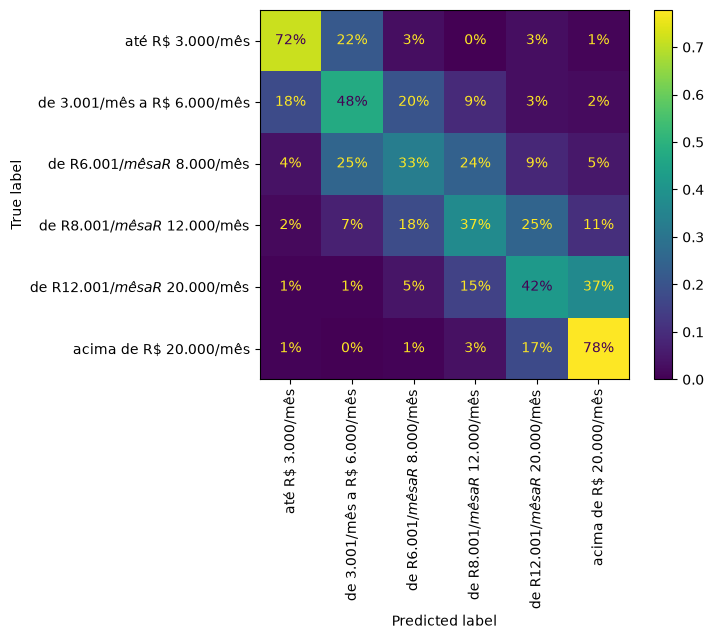

In [8]:
cm = confusion_matrix(y_test, predicts)

ConfusionMatrixDisplay.from_predictions(y_true=y_test,
                                        y_pred=predicts,
                                        labels=y_test.cat.categories,
                                        normalize='true',
                                        values_format='.0%',
                                        xticks_rotation='vertical')

### CONCLUSÃO

_Como fechamento desse projeto, o modelo chegou em um limiar de f1-score, considerando macro avg, de 49% tanto no set de validação quanto no test-set, logo isso representa que o modelo generalizou muito bem, apesar de diferenças sutis em algumas faixas categóricas entre o modelo no test-set e no de validação_

- CONCLUSÕES FINAIS:
    - As faixas de 6.000 a 8000 e de 8.001 a 12.000 são o ponto fraco do modelo, mas a taxa de erro aponta principalmente para as classes vizinhas, pois as pessoas que ganham 7.900 e 8.100 tem quase o mesmo perfil, mas isso comprova que o modelo identificou e capturou a estrutura ordinal sobre as faixas salariais, pois os erros são majoritariamente em faixas vizinhas.
    - Os extremos foram muito beneficiados com o class-weight balanced ( mesmo que já fossem bons por conta de so terem uma classe vizinhas ).
    - O modelo Logistic Regressor Balanced foi o que apresentou melhor comportamento na validação com cross_validation entre os modelos avaliados, por isso foi escolhido como modelo final.
        - Fiz o teste com o modelo de RandomForestClassifier e ele se adaptou melhor ao test_set, mas escolher um modelo a partir do test_set é vazamento de dados, então o modelo foi escolhido categoricamente com base no test de validação.
    - Para esse modelo a acurácia em geral foi 48%, o que se aproximou bem do comportamento real do modelo, isso se da por conta dos dados estarem bem distribuidos, sem heavy_tail e com desbalanceamento moderado. Isso é consequencia de uma decisão no inicio do projeto (reduzir de 13 categorias para apenas 6 distribuindo de forma mais homogenea os dados ).

- FECHAMENTO COM V1: 
    - O modelo v1 (de Regressão ) foi pensado como problema de regressão, mas ao analisar o target ficou claro que na verdade se tratava de um problema de classificação. Ao prosseguir com a analise, os dados comprovaram essa suspeita e no momento que identifiquei uma barreira para um modelo de regressão ( prever um valor contínuo sobre faixas discretizadas, gerando um teto estrutural para o modelo ) optei por estudar como um modelo de classificação opera e aplicar esses conhecimentos nesse projeto, resultando em um modelo com aproximadamente 48% de acurrácia e 49% de f1_score com macro avg, com desempenho estável entre validação e teste.
    